In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("carData.csv")


In [137]:
print("dimensions de jeu de donné", df.shape)
print(df.head())

dimensions de jeu de donné (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [138]:
k= df.sort_values(by=['Selling_Price'], ascending=False)
print(k[['Selling_Price']].head())
      

    Selling_Price
86           35.0
64           33.0
63           23.5
82           23.0
51           23.0


In [139]:
a=df.sort_values(by=['Present_Price'], ascending=False)
print(a[['Present_Price']].head())

    Present_Price
86          92.60
64          36.23
59          35.96
62          35.96
63          35.96


In [140]:
dies=df[df["Fuel_Type"]=="Diesel"]
print(dies.head())

        Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
1            sx4  2013           4.75           9.54       43000    Diesel   
4          swift  2014           4.60           6.87       42450    Diesel   
5  vitara brezza  2018           9.25           9.83        2071    Diesel   
7        s cross  2015           6.50           8.61       33429    Diesel   
8           ciaz  2016           8.75           8.89       20273    Diesel   

  Seller_Type Transmission  Owner  
1      Dealer       Manual      0  
4      Dealer       Manual      0  
5      Dealer       Manual      0  
7      Dealer       Manual      0  
8      Dealer       Manual      0  


In [141]:
petr=df[df["Fuel_Type"]=="Petrol"]
print(petr.head())

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
6       ciaz  2015           6.75           8.12       18796    Petrol   
10  alto 800  2017           2.85           3.60        2135    Petrol   

   Seller_Type Transmission  Owner  
0       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
6       Dealer       Manual      0  
10      Dealer       Manual      0  


In [142]:
print("Quelque stats autours du prix de vente:\n")
print("prix moyen:", df['Selling_Price'].mean())
print("Prix médian:", df['Selling_Price'].median())
print("Quartiles prix de vente\n", df['Selling_Price'].quantile([0.25, 0.5,0.75]),"\n")

Quelque stats autours du prix de vente:

prix moyen: 4.661295681063123
Prix médian: 3.6
Quartiles prix de vente
 0.25    0.9
0.50    3.6
0.75    6.0
Name: Selling_Price, dtype: float64 



In [143]:
print("Quelque stats autours du prix sur le marché:\n")
print("Prix moyen sur le marché:", df['Present_Price'].mean())
print("Prix median sur le marché:", df['Present_Price'].median())
print("Quartiles prix sur le marché:\n", df['Present_Price'].quantile([0.25,0.5,0.75]),"\n")

Quelque stats autours du prix sur le marché:

Prix moyen sur le marché: 7.628471760797343
Prix median sur le marché: 6.4
Quartiles prix sur le marché:
 0.25    1.2
0.50    6.4
0.75    9.9
Name: Present_Price, dtype: float64 



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


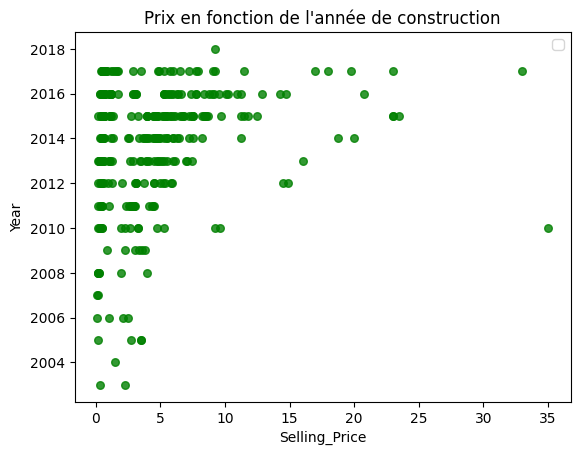

In [144]:
x=df["Selling_Price"]
y=df["Year"]
plt.scatter(x,y,color='green', s=30, alpha=0.8)
plt.title("Prix en fonction de l'année de construction")
plt.xlabel('Selling_Price')
plt.ylabel('Year')
plt.legend()
plt.show()

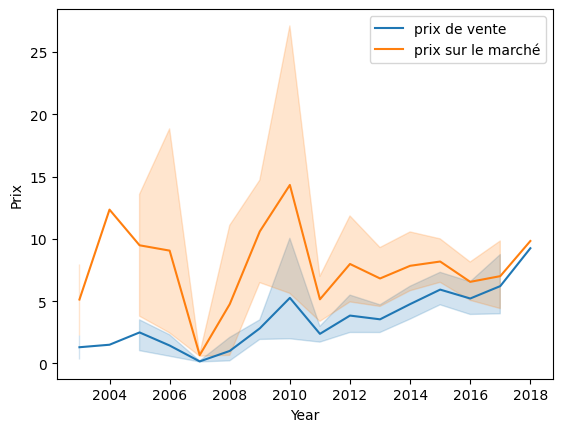

In [145]:
sns.lineplot(data=df, x="Year",y="Selling_Price", label="prix de vente")
sns.lineplot(data=df, x="Year", y="Present_Price", label="prix sur le marché")
plt.ylabel("Prix")
plt.show()

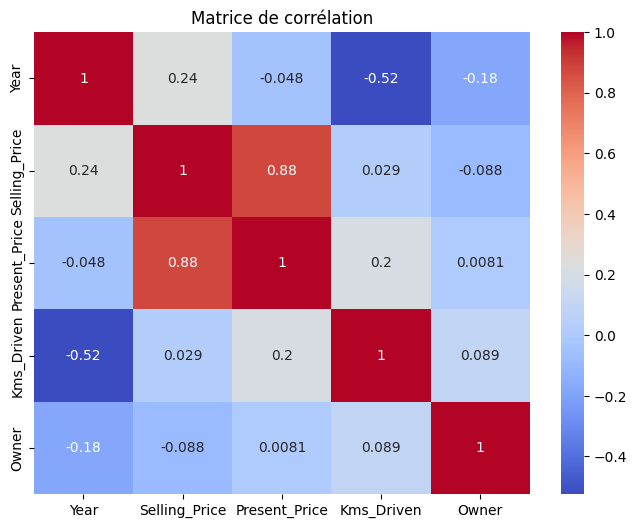

In [146]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [147]:
print( "ici on calcule la correlation de pearson entre le prix de vente et l'année:")
correlationPearson= df["Selling_Price"].corr(2018-df["Year"])
print(correlationPearson)

ici on calcule la correlation de pearson entre le prix de vente et l'année:
-0.23614098016042756


Text(0, 0.5, 'nombre de voiture')

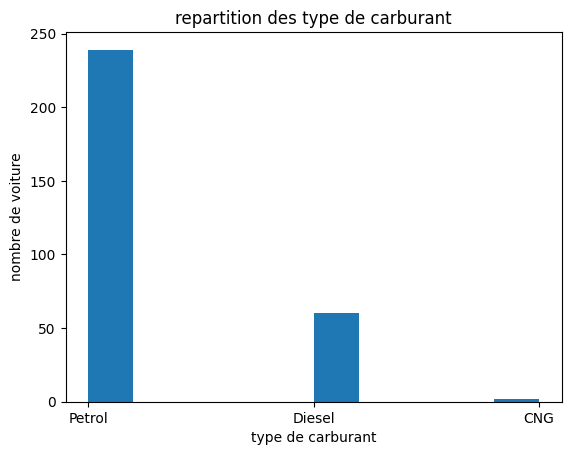

In [148]:
plt.hist(df["Fuel_Type"])
plt.title("repartition des type de carburant")
plt.xlabel("type de carburant")
plt.ylabel("nombre de voiture")

Text(0, 0.5, 'nombre de voiture')

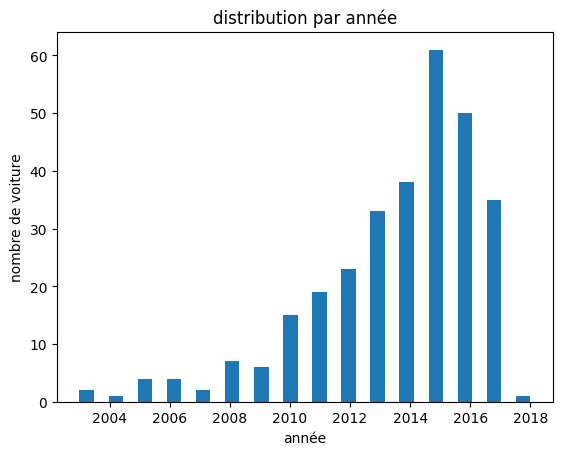

In [149]:
plt.hist(df["Year"], bins=31)
plt.title("distribution par année")
plt.xlabel("année")
plt.ylabel("nombre de voiture")

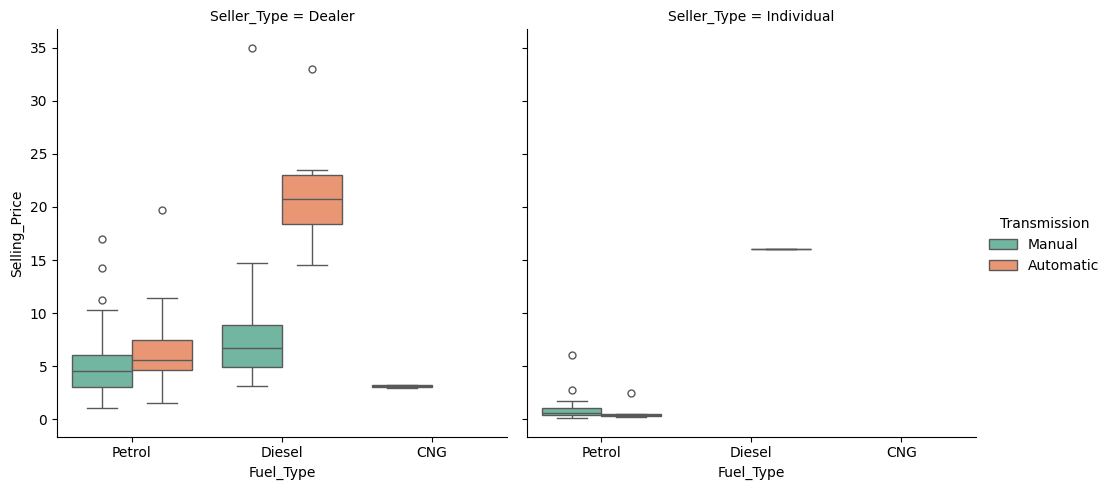

In [150]:
sns.catplot(data=df, x="Fuel_Type", y="Selling_Price",hue="Transmission",col="Seller_Type", kind="box",palette="Set2")

In [151]:
# le diagramme catplot est pertinent pour comparer une variable numérique avec 
# des variables qualitative, dans ce cas la on voudrait comparé le prix 
# avec les differentes qualités

<Axes: xlabel='Year', ylabel='Selling_Price'>

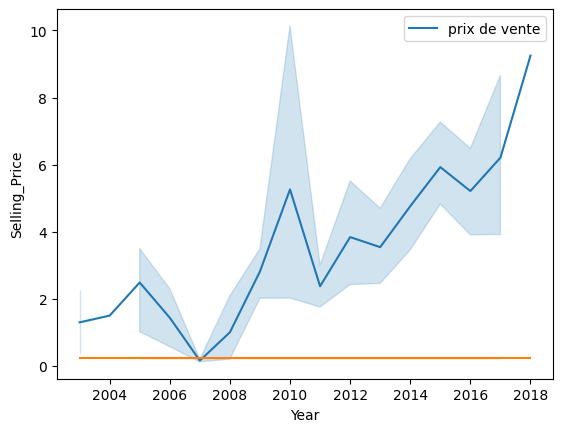

In [152]:
sns.lineplot(data=df, x="Year", y="Selling_Price", label="prix de vente")
sns.lineplot(data=df, x="Year", y=df["Selling_Price"].corr(df["Year"]))
#print("correlation de pearson",y)

In [153]:
# le jeu de donnée est adapté à la regression lineaire sur les variables de prix, kilometrage
#et age mais pas pour la transmission, vendeur, type de carburant car ce sont des variable qualitative

In [154]:
pearson_corr = df['Selling_Price'].corr(df['Year'])
print(f"Correlation de Pearson entre Selling_Price et Year : {pearson_corr:.2f}")

Correlation de Pearson entre Selling_Price et Year : 0.24


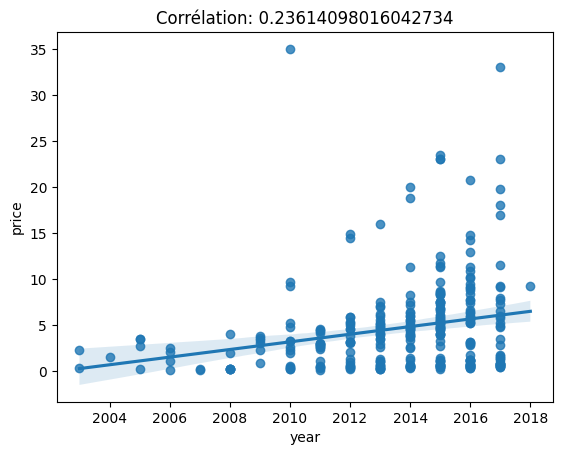

In [155]:
x=df["Year"]
y=df["Selling_Price"]
r=x.corr(y)
sns.regplot(x=x,y=y)
plt.title(f"Corrélation: {r}")
plt.xlabel("year")
plt.ylabel("price")
plt.show()

Pente : 0.42
Intercept : -831.18
R-carré : 0.06


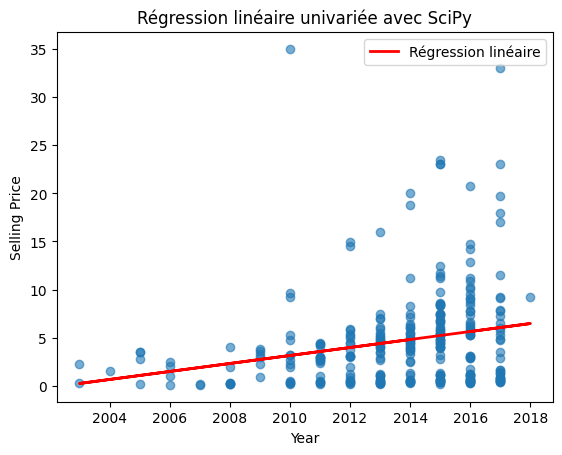

In [156]:
from scipy import stats
x=df["Year"]
y=df["Selling_Price"]

slope,intercept,r_value,p_value,std_err=stats.linregress(x,y)
print(f"Pente : {slope:.2f}")
print(f"Intercept : {intercept:.2f}")
print(f"R-carré : {r_value**2:.2f}")

plt.scatter(x, y, alpha=0.6)
plt.plot(x, slope*x + intercept, color='red', linewidth=2, label='Régression linéaire')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.title('Régression linéaire univariée avec SciPy')
plt.legend()
plt.show()

R² : 0.21
RMSE : 4.26


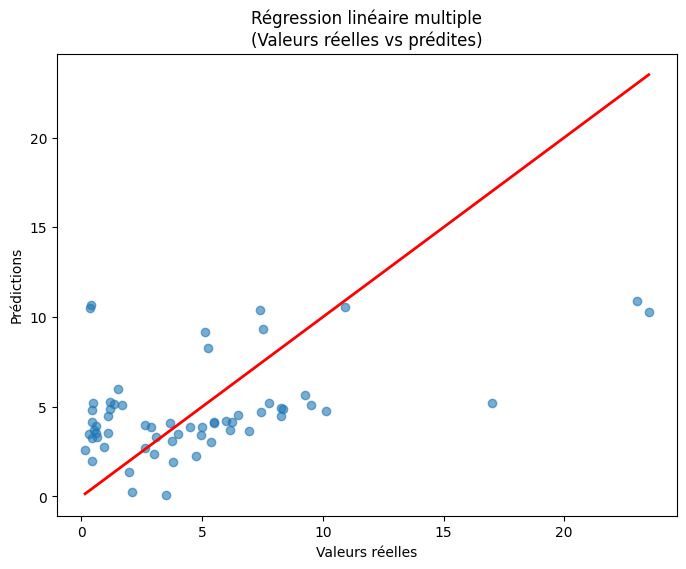

In [157]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Charger les données
df = pd.read_csv('carData.csv')

# Variables
X = df[['Kms_Driven', 'Year', 'Transmission']]
y = df['Selling_Price']

# Encodage de Transmission
preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), ['Transmission'])
    ],
    remainder='passthrough'
)

# Pipeline
model = Pipeline([
    ('preprocess', preprocessor),
    ('regression', LinearRegression())
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² : {r2:.2f}")
print(f"RMSE : {rmse:.2f}")

# 📊 Graphique : valeurs réelles vs prédites
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Droite parfaite (y = x)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Régression linéaire multiple\n(Valeurs réelles vs prédites)")
plt.show()

In [158]:
# nous obtenons un r carré de 0.21 ce qui est assez peu mais nous avons pu trouver des nouveau 
# facteur en ajoutant le kilometrage et la transmission. Le r carré n'étatnt pas de 1
# cela signifie qu'il y a plusieur autre facteur qui intervienne dans le prix dont
# nous avons pas de donné, on peut citer par exemple la marque et le model de la voiture, 
#la puissance du moteur

   Year  Kms_Driven Transmission  Predicted_Price
0  2011      100000       Manual         3.472826
1  2012      100000       Manual         3.977076
2  2013      100000       Manual         4.481327
3  2014      100000       Manual         4.985578
4  2015      100000       Manual         5.489828
5  2016      100000       Manual         5.994079
6  2017      100000       Manual         6.498329
7  2018      100000       Manual         7.002580


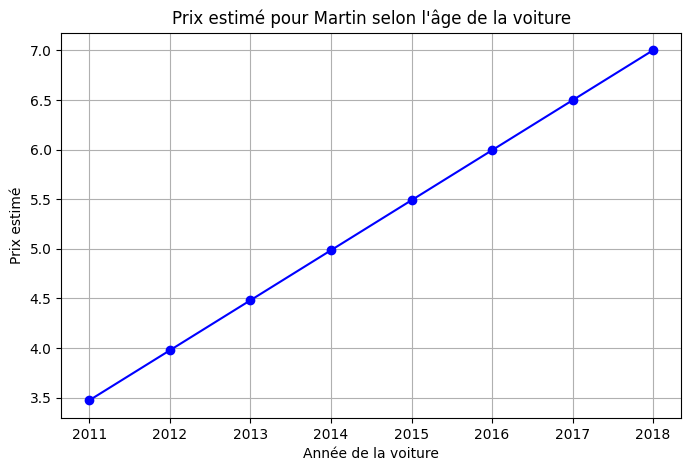

In [159]:

# Années possibles pour une voiture ≤ 7 ans en 2018
years = list(range(2011, 2019))  # 2011 à 2018 inclus

# Créer le DataFrame
martin_cars = pd.DataFrame({
    'Year': years,
    'Kms_Driven': [100000]*len(years),  # ≤ 100 000 km
    'Transmission': ['Manual']*len(years)
})
predicted_prices = model.predict(martin_cars)
martin_cars['Predicted_Price'] = predicted_prices

print(martin_cars)

plt.figure(figsize=(8,5))
plt.plot(martin_cars['Year'], martin_cars['Predicted_Price'], marker='o', color='blue')
plt.xlabel("Année de la voiture")
plt.ylabel("Prix estimé")
plt.title("Prix estimé pour Martin selon l'âge de la voiture")
plt.grid(True)
plt.show()

R² : 0.59
RMSE : 3.07


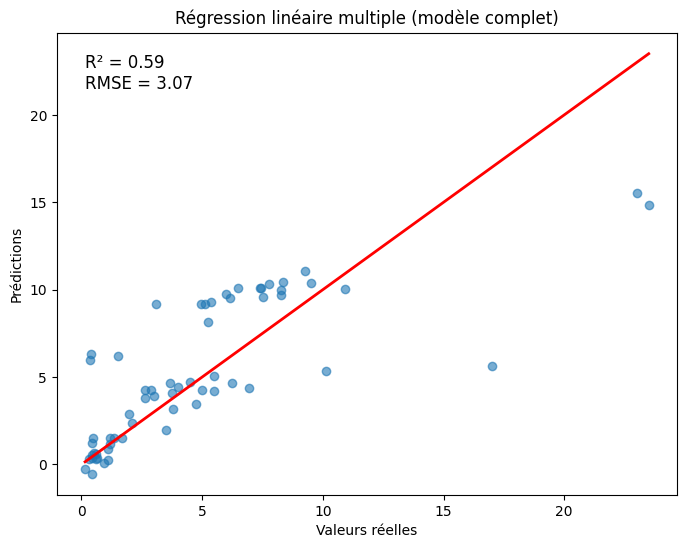

In [160]:


# Charger les données
df = pd.read_csv('carData.csv')

# Variables
X = df[['Year', 'Kms_Driven', 'Transmission', 'Fuel_Type', 'Seller_Type']]
y = df['Selling_Price']

# Variables catégorielles
categorical_features = ['Transmission', 'Fuel_Type', 'Seller_Type']

# Prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

# Pipeline
model = Pipeline([
    ('preprocess', preprocessor),
    ('regression', LinearRegression())
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² : {r2:.2f}")
print(f"RMSE : {rmse:.2f}")

# 📊 Graphique
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Ligne parfaite
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

# Texte avec métriques
plt.text(
    x=y_test.min(),
    y=y_test.max(),
    s=f"R² = {r2:.2f}\nRMSE = {rmse:.2f}",
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Régression linéaire multiple (modèle complet)")
plt.show()